In [1]:
import numpy as np 
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from typing import Sequence

from qiskit import QuantumCircuit

from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.circuit.library import XGate

from qiskit_aer.primitives import EstimatorV2
from qiskit.primitives.base import BaseEstimatorV2
from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler.passes.scheduling import (
    ALAPScheduleAnalysis,
    PadDynamicalDecoupling,
)

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Session, Estimator
from qiskit_ibm_runtime.fake_provider import FakeBrisbane


### Initialize hardware

The `FakeBrisbane()` backend comes equipped with a noise model based on the real Brisbane device. 

In [2]:

# --- BACKEND SELECTION ---
USE_SIMULATOR = True   # flip to False for real IBM backend

if USE_SIMULATOR:
    # Noiseless simulator mimicking FakeBrisbane topology
    backend = FakeBrisbane()
    transpile_target = backend.target   # use layout/topology only
    estimator = EstimatorV2()
else:
    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False)
    transpile_target = backend.target
    estimator = Estimator(backend)


# --- PASS MANAGER ---
pm = generate_preset_pass_manager(
    optimization_level=3,
    backend=backend,
    routing_method="sabre"
)

# Only add scheduling/DD if running on a real backend
if not USE_SIMULATOR:
    durations = transpile_target.durations()
    pm.scheduling = PassManager(
        [
            ALAPScheduleAnalysis(durations=durations),
            PadDynamicalDecoupling(
                durations=durations,
                dd_sequence=[XGate(), XGate()],
                pulse_alignment=transpile_target.pulse_alignment,
            ),
        ]
    )


In [3]:
print("Using backend:", backend)

Using backend: <qiskit_ibm_runtime.fake_provider.backends.brisbane.fake_brisbane.FakeBrisbane object at 0x1317039b0>


### Define Hamiltonian

In [4]:
def H_tfi(N, g=0.0, J=1.0, PBC=True):
    """Construct the N-qubit transverse field Ising model Hamiltonian."""

    h_field = [("X", [n], -g) for n in range(N)]
    if PBC:
        J_zz = [("ZZ", [n, (((n+1) % N) % N) % N], -J) for n in range(N)]
    else:
        J_zz = [("ZZ", [n, n+1], -J) for n in range(N-1)]
    

    operator_tuples = [*h_field, *J_zz]
    H =  SparsePauliOp.from_sparse_list(operator_tuples, num_qubits=N)
    return H.simplify()
    

### Define Ansatz

In [5]:
def get_PBC_symm_ansatz(N, num_layers=1):
    """Symmetry-preserving ansatz for the transverse field Ising model with periodic boundary conditions.
    
    Args:
        N (int): Number of qubits (spins).
        num_layers (int): Number of layers in the ansatz.
        Returns: Parametrized QuantumCircuit object representing the ansatz."""

    theta = ParameterVector('th', 3*num_layers) # Does not depend on N
    phi = ParameterVector('phi', num_layers)

    symm_ansatz = QuantumCircuit(N)

    symm_ansatz.h([n for n in range(N)])

    for layer in range(num_layers):
        params = [theta[i + 3*layer] for i in range(3)]

        # Apply sigma gates in brick structure
        for n in range(N//2):
            sigma_gates(symm_ansatz, 2*n, 2*n+1, params)
        for n in range(1, N//2 +1):
            sigma_gates(symm_ansatz, 2*n-1, (2*n)%N, params)
        
        # The loop above only applies sigma gates between qubits 0 and N-1 if N is even.
        # To apply these gates when N is odd, manually apply a sigma gate between qubits 0 and N-1.
        if N % 2 == 1:
            sigma_gates(symm_ansatz, N-1, 0, params)
            
        # Apply RX gates
        symm_ansatz.rx(phi[layer], [n for n in range(N)])
        

    return symm_ansatz

def sigma_gates(circuit, n, m, params):
    """Mathematically identical to applying Rxx, Ryy, then Rzz to qubits (n, m) in circuit.
    Args:
        circuit (QuantumCircuit): The quantum circuit to which the gates will be applied.
        n (int): The index of the first qubit.
        m (int): The index of the second qubit.
        params (list or array-like): A list or array of three parameters [param0, param1, param2] for the rotations about each axis.
    """
    circuit.cx(m, n)
    circuit.rz(params[0], n)
    circuit.h(m)
    circuit.rz(params[1] + np.pi/2, m)
    circuit.cx(m, n)
    circuit.rz(-params[2], n)
    circuit.h(m)
    circuit.cx(m, n)
    circuit.sx(n)
    circuit.sxdg(m)


    

### Create instance of the ansatz and transpile

If using a simulator, the transpiler will map the ansatz to IBM Brisbane (since the fake backend mimics IBM Brisbane's topology). 

In [6]:
N = 4 # number of qubits

ansatz = get_PBC_symm_ansatz(N, num_layers=N//2)
ansatz_ibm = pm.run(ansatz)

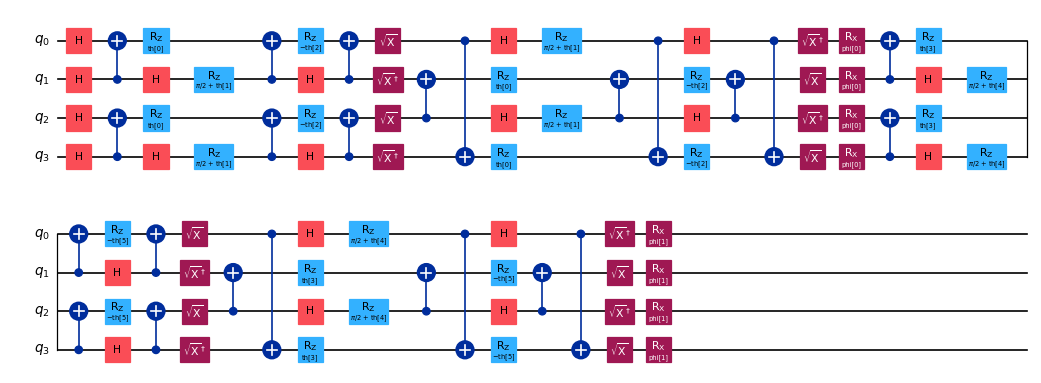

In [7]:
ansatz.draw("mpl", scale=0.6, style="iqp", idle_wires=False)

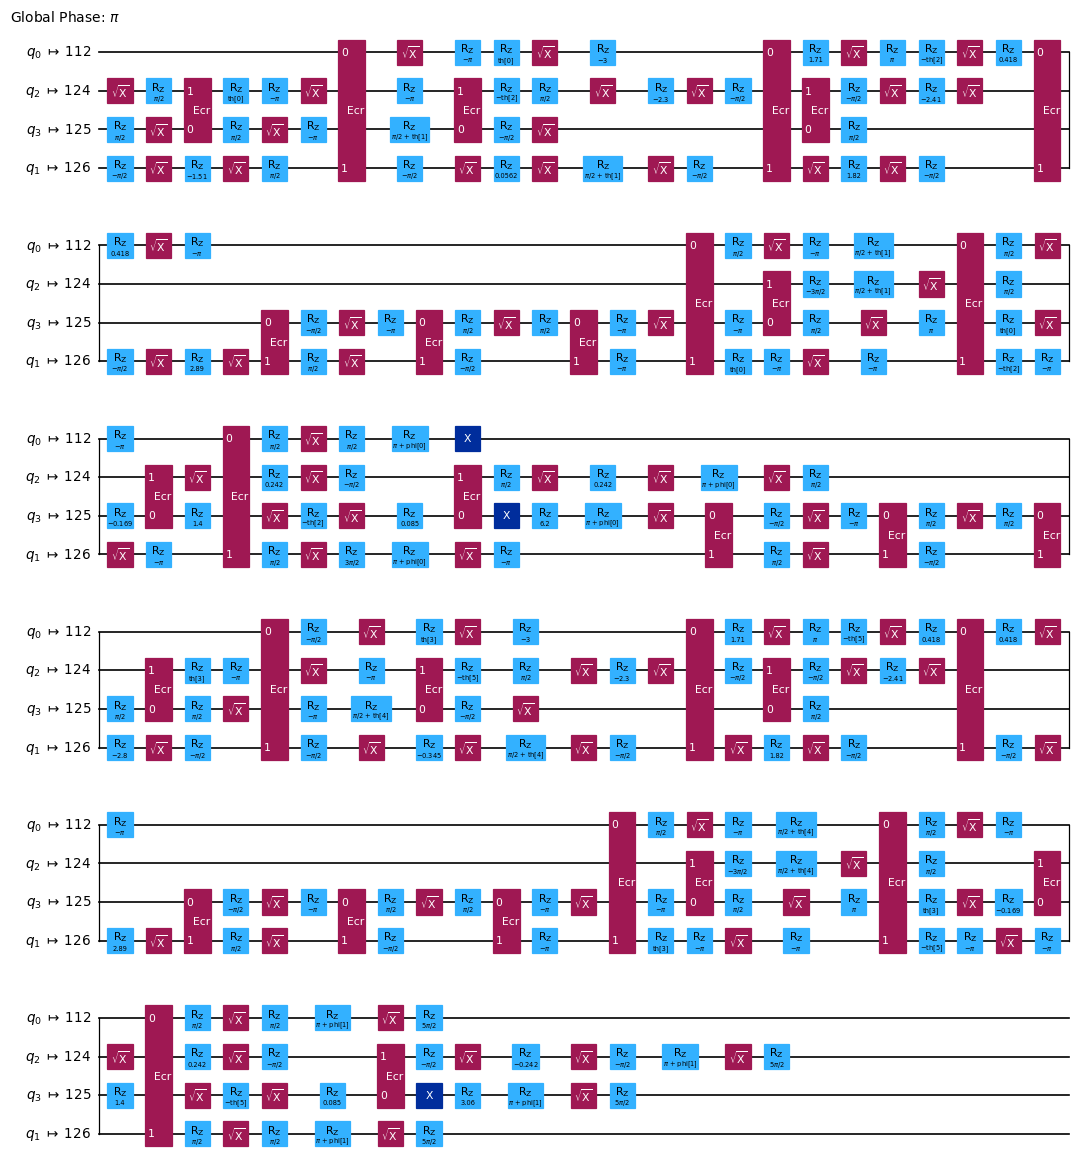

In [8]:
ansatz_ibm.draw("mpl", scale=0.6, style="iqp", idle_wires=False)

### Define Cost function

Cost function which also builds the cost history dict. 

In [9]:
def cost_func(
    params: Sequence,
    ansatz: QuantumCircuit,
    hamiltonian: SparsePauliOp,
    estimator: BaseEstimatorV2,
    g: float,
) -> float:

    """Return estimate of energy from estimator
    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        g (float): Transverse field strength
    Returns:
        float: Energy estimate
    """
    pub = (ansatz, [hamiltonian], params)
    job = estimator.run([pub], precision=1e-6)
    result = job.result()[0]
    energy = result.data.evs[0]
    
    
    cost_history_dict[str(g)]["iters"] += 1
    cost_history_dict[str(g)]["prev_vector"] = params
    cost_history_dict[str(g)]["cost_history"].append(energy)
    print(f"g={g} Iters. done: {cost_history_dict[str(g)]['iters']} [Current cost: {energy}]", 
            end="\r",
            flush=True)

    return energy

### Define VQE routine
Wrap the VQE routine so that the caller can iterate over different values of $g$.

In [ ]:
def get_vqe_gs(ansatz_ibm, estimator, g):

    num_params = ansatz_ibm.num_parameters
    params = 0.01 * np.random.random(num_params)   # initial parameters near zero
    
    hamiltonian = H_tfi(N, g=g, J=1.0, PBC=True) # construct hamiltonian for given g
    hamiltonian_ibm = hamiltonian.apply_layout(ansatz_ibm.layout) #transpile hamiltonian to match ansatz layout

    # --- ESTIMATOR AND OPTIMIZER OPTIONS ---
    estimator.options.default_shots = 500 
    options = {'maxiter': 5000, 'rhobeg': 0.1} 

    res = minimize(
        cost_func,
        x0=params,
        args=(ansatz_ibm, hamiltonian_ibm, estimator, g),
        method="cobyla",
        options=options,
    )
    energy = res.fun
    final_params = res.x
    return energy, final_params




### Pick set of $g$ values

In [11]:
gs = np.linspace(0.0, 2.0, 5)  # transverse field strengths. 
                            # Note that the last argument determines how many g values are run through VQE

## Execute on hardware

Note: the IBM open plan does not allow me to run a `Session()`, which is ideal for running VQE. The code below can only be run if (i) you have access to a premium plan or (ii) if you're running a fake backend such as `FakeBrisbane()`.

In [29]:

E_GS_qiskit = [] #List to store ground state energies for each g
params_list = [] #List to store optimal parameters for each g

#Initialize cost history dictionary
outter_keys = [str(g) for g in gs]
inner_keys = ["prev_vector", "iters", "cost_history"]

cost_history_dict = {}
for outter_key in outter_keys:
    cost_history_dict[outter_key] = {}
    cost_history_dict[outter_key]["prev_vector"] = None
    cost_history_dict[outter_key]["iters"] = 0
    cost_history_dict[outter_key]["cost_history"] = []


# Evaluate the problem using a QPU via Qiskit IBM Runtime
with Session(backend=backend) as session:
    
    for g in gs:
        E_vqe, params = get_vqe_gs(ansatz_ibm, estimator, g)
        E_GS_qiskit.append(E_vqe)
        params_list.append(params)


## Post Processing

### Plot cost history

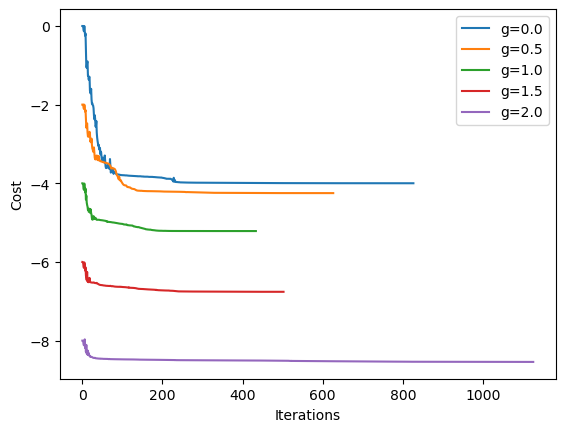

In [30]:
fig, ax = plt.subplots()
for g in gs:
    ax.plot(range(cost_history_dict[str(g)]["iters"]), cost_history_dict[str(g)]["cost_history"], label=f"g={g}")
ax.legend()
ax.set_xlabel("Iterations")
ax.set_ylabel("Cost")

plt.draw()

### Reconstruct optimal circuit(s) and statevector(s)

Note that the circuits stored in the list are not transpiled. If using in a larger algorithm, just transpile using the pass manager.

In [31]:
psi_GS_qiskit = []
circuit_vqe_list = []

for params in params_list:
    ansatz = get_PBC_symm_ansatz(N, num_layers=N//2) #Recreate ansatz to avoid parameter binding issues
    circuit_vqe = ansatz.assign_parameters(params)
    psi_vqe = Statevector(circuit_vqe)
    
    psi_GS_qiskit.append(psi_vqe)
    circuit_vqe_list.append(circuit_vqe)
    

## Compare with exact diagonalization in Quspin

In [32]:
import numpy as np 
import matplotlib.pyplot as plt # plotting library
#plt.rcParams["text.usetex"] = True

import os
os.environ['OMP_NUM_THREADS'] = '8'
os.environ['MLK_NUM_THREADS'] = '8'

from quspin.operators import hamiltonian 
from quspin.basis import spin_basis_1d

import matplotlib.pyplot as plt


### Define Hamiltonian in Quspin

In [33]:
def H_tfi_quspin(N, J=1.0, g=0.0, PBC=True): 

    h_field=[[-g,i] for i in range(N)]
    if PBC:
        J_zz=[[-J, i, (i+1) % N] for i in range(N)]
    else:
        J_zz=[[-J, i, i+1] for i in range(N-1)] 
    static_spin =[["zz",J_zz],["x",h_field]]
    dynamic_spin=[]
    basis_spin = spin_basis_1d(L=N)
    
    H_spin=hamiltonian(static_spin, dynamic_spin, basis=basis_spin, dtype=np.complex64, check_herm=False, check_symm=False)
    return H_spin

### Find the ground state

In [34]:

E_GS_quspin = []
psi_GS_quspin = []

for g in gs:
    H = H_tfi_quspin(N, J=1.0, g=g, PBC=True)
    E, V = H.eigsh(k=1, which='SA')
    E_GS_quspin.append(E[0])
    psi_GS_quspin.append(V)


In [35]:
#Fractional error
E_GS_quspin = np.array(E_GS_quspin)
error = np.abs((E_GS_quspin-E_GS_qiskit)/E_GS_quspin)

#Overlap
overlap_arr = np.zeros(len(gs))

for i in range(len(gs)):
    overlap_sqrt = np.abs(np.vdot(psi_GS_quspin[i], psi_GS_qiskit[i]))
    overlap_arr[i] = overlap_sqrt**2    

## Plot comparison

<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\p'
/var/folders/26/3g2wy1kx0k72dhg7_ycw5c5c0000gr/T/ipykernel_94574/1844496295.py:28: SyntaxWarning: invalid escape sequence '\p'
  ax3.set_ylabel('$|\\langle \psi_{VQE} | \psi_{quspin} \\rangle |^2$')


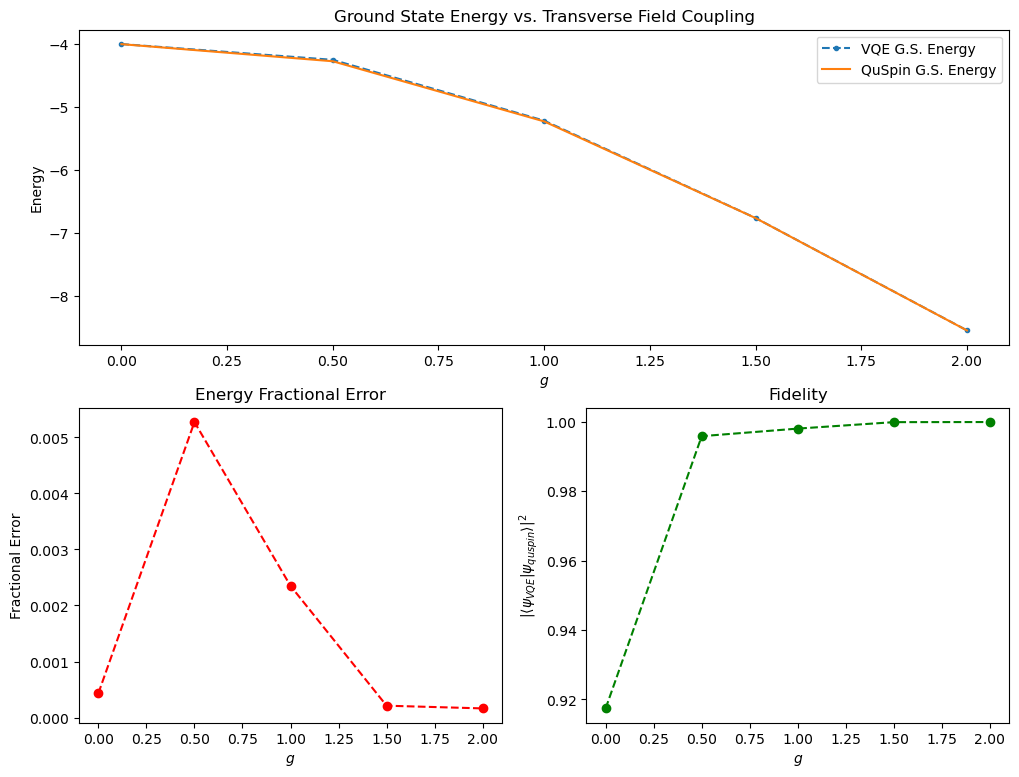

In [36]:
layout = [['A panel', 'A panel'],
         ['B panel', 'C panel',]]
fig, axd = plt.subplot_mosaic(layout, figsize=(12, 9))
ax1 = axd['A panel']
ax1.plot(gs, E_GS_qiskit, '--.', label='VQE G.S. Energy')
ax1.plot(gs, E_GS_quspin, label='QuSpin G.S. Energy')

ax1.set_title('Ground State Energy vs. Transverse Field Coupling')
ax1.set_xlabel('$g$')
ax1.set_ylabel('Energy')
ax1.legend()

#text_str = " Parameters \n Optimizer: {} \n Entanglement: {} \n Gates: {} \n 
# Layers : {} \n N: {}".format(optimizer_name, entanglement, gates, layers, N)
#ax1.text(gs.min(), np.mean(E_gs_qiskit), text_str)

ax2 = axd['B panel']
ax2.plot(gs, error, '--o', color='red')
ax2.set_title('Energy Fractional Error')
ax2.set_xlabel('$g$')
ax2.set_ylabel('Fractional Error')

ax3 = axd['C panel']
ax3.plot(gs, overlap_arr, '--o', color='green', label="without $S$")

ax3.set_title('Fidelity')
ax3.set_xlabel('$g$')
ax3.set_ylabel('$|\\langle \psi_{VQE} | \psi_{quspin} \\rangle |^2$')

#fname = "TFI_VQE_plots_N={}_ansatz=symm_layers={}".format(N, N/2)

#plt.savefig(fname + '.pdf')
#ansatz.draw('mpl').savefig(circuit_fname + '.pdf')


plt.show()